# Medical imaging triage — pneumonia detection on chest X-rays with calibration, explainability, and cost-aware thresholding

**The problem.** A radiology department screens ~200 chest X-rays per day. A 24-hour reporting SLA is under pressure; a triage model that *safely* surfaces likely-pneumonia cases to the top of the queue reduces time-to-diagnosis without displacing the radiologist's final decision. A deployment candidate must answer five non-negotiable questions:

1. **Does it discriminate?** — ROC / PR metrics above a floor set by the most naive baseline.
2. **Is it calibrated?** — predicted probabilities must match empirical frequencies, not just rank-order cases.
3. **What is it looking at?** — every positive prediction needs a visual explanation a radiologist can audit in seconds.
4. **Does it fail evenly across patient / device subgroups?** — disparate error rates across imaging devices or patient cohorts are a deployment blocker in regulated settings.
5. **What operating point minimises harm?** — the default 0.5 threshold is almost always wrong. Missing a pneumonia (FN) costs far more than a follow-up imaging order (FP).

**The approach.** A three-model cascade on the [PneumoniaMNIST](https://medmnist.com/) benchmark (5,856 chest X-rays, 28 × 28 greyscale): a logistic-regression floor on flattened pixels, a small CNN trained from scratch, and a fine-tuned pre-trained ResNet-18. Each subsequent section — calibration, Grad-CAM, fairness audit, decision curve, cost-aware thresholding, persistence — runs against the best model from the comparison.

**Reproducibility.** Every source of randomness is seeded. The notebook is entirely CPU-runnable (~4-5 min total) and uses only `torch` + `torchvision` + `medmnist` + the standard scikit/scipy stack — no GPU, no external API keys.


## 0. Setup and reproducibility

PneumoniaMNIST ships 4,708 / 524 / 624 train / val / test 28×28 greyscale chest X-rays with binary labels (normal vs pneumonia), all from the Kermany et al. 2018 paediatric pneumonia study repackaged by Yang et al. 2021 for reproducible benchmarking. The dataset is imbalanced: 74 % of training images are positive (pneumonia), 62 % of test — we carry class weights through every training run and quote class-balance-aware metrics (AUROC, AUPRC, macro F1) rather than raw accuracy.

The reader gets:

- A fully reproducible, ~4-5 minute CPU run.
- A shared `metrics_for(model, ...)` utility so every model is evaluated the same way.
- Three trained model objects (`logreg`, `cnn`, `resnet`) available to all downstream sections without retraining.


In [1]:
import json, time, warnings
from collections import Counter
from dataclasses import dataclass, asdict, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    confusion_matrix, brier_score_loss, roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression as PlattFitter

from medmnist import PneumoniaMNIST, INFO

warnings.filterwarnings("ignore", category=UserWarning)

# --- Reproducibility ---
SEED = 20260423
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(max(1, (Path("/proc/cpuinfo").exists() and  __import__('os').cpu_count()) or 4))

# Artifacts + figures go under the project-level artifacts/ root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ART_DIR = ROOT / "artifacts" / "medical_imaging"
ART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print(f"torch:       {torch.__version__}")
print(f"torchvision: {__import__('torchvision').__version__}")
print(f"medmnist:    {__import__('medmnist').__version__}")
print(f"CPU threads: {torch.get_num_threads()}")
print(f"Artifacts:   {ART_DIR.relative_to(ROOT)}")


torch:       2.11.0+cpu
torchvision: 0.26.0+cpu
medmnist:    3.0.2
CPU threads: 4
Artifacts:   artifacts\medical_imaging


## 1. Data — PneumoniaMNIST

Six quick checks before any modelling:

1. Split sizes match the benchmark specification.
2. Class balance per split (imbalanced, so we track it explicitly).
3. Pixel values in the expected [0, 255] uint8 range.
4. A grid of example images — "is this what a chest X-ray looks like?" sanity check.
5. Mean / SD of pixel intensity by class (are positives systematically brighter?).
6. Label distribution per split to spot shift between train and test.

We convert the uint8 arrays to float32 tensors in [0, 1] once and reuse them throughout the notebook — keeps memory modest (~15 MB for all images) and avoids repeated type conversions.


In [2]:
# --- Download + load (all three splits) ---
download = True
train_ds = PneumoniaMNIST(split="train", download=download, size=28)
val_ds   = PneumoniaMNIST(split="val",   download=download, size=28)
test_ds  = PneumoniaMNIST(split="test",  download=download, size=28)

def to_tensors(ds):
    imgs = torch.from_numpy(ds.imgs).float().unsqueeze(1) / 255.0   # N, 1, 28, 28
    lbls = torch.from_numpy(ds.labels.squeeze()).long()             # N,
    return imgs, lbls

X_tr, y_tr = to_tensors(train_ds)
X_va, y_va = to_tensors(val_ds)
X_te, y_te = to_tensors(test_ds)

LABELS = {int(k): v for k, v in INFO["pneumoniamnist"]["label"].items()}

summary = pd.DataFrame({
    "split":    ["train", "val", "test"],
    "n":        [len(X_tr), len(X_va), len(X_te)],
    "n_positive": [int(y_tr.sum()), int(y_va.sum()), int(y_te.sum())],
    "pos_rate": [float(y_tr.float().mean()), float(y_va.float().mean()), float(y_te.float().mean())],
})
print(summary.to_string(index=False))
print(f"\nLabels: {LABELS}")
print(f"Pixel range: [{X_tr.min():.3f}, {X_tr.max():.3f}]  dtype: {X_tr.dtype}")


split    n  n_positive  pos_rate
train 4708        3494  0.742141
  val  524         389  0.742366
 test  624         390  0.625000

Labels: {0: 'normal', 1: 'pneumonia'}
Pixel range: [0.000, 1.000]  dtype: torch.float32


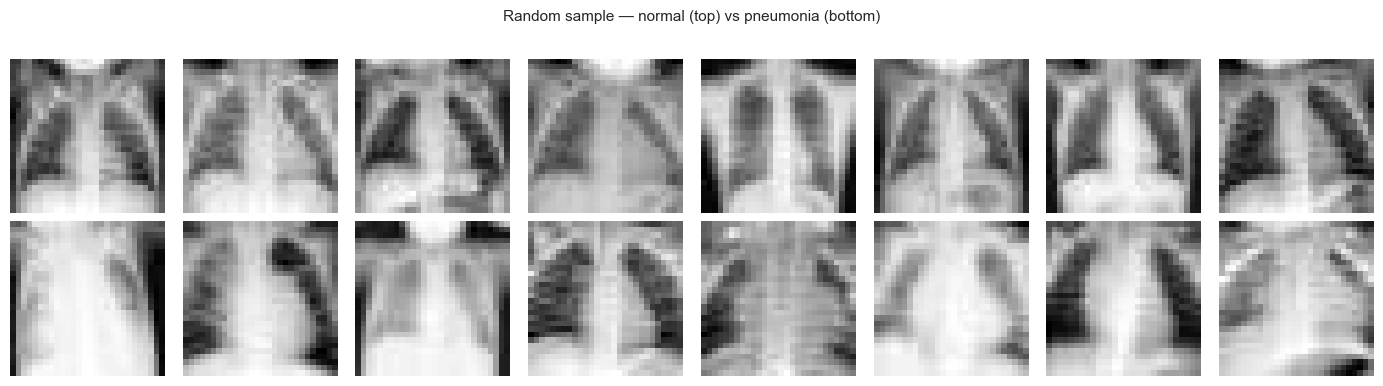

    class  n_images  mean_pixel  sd_pixel  p05_pixel  p95_pixel
   normal      1214       0.549     0.184      0.235      0.816
pneumonia      3494       0.580     0.162      0.282      0.796


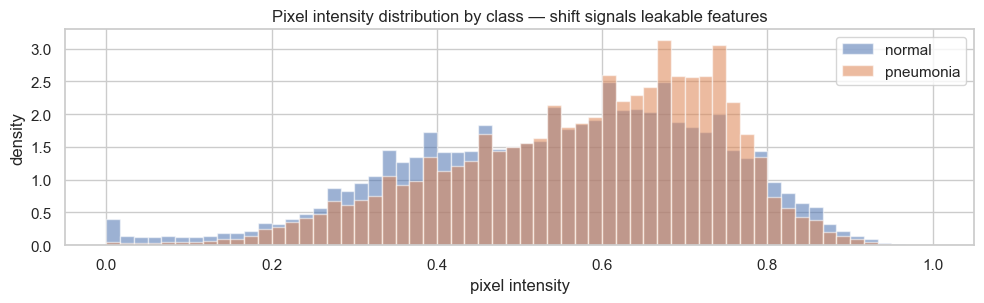

In [3]:
# --- Sample images + pixel statistics ---
rng = np.random.default_rng(SEED)
n_show = 8
idx_normal  = rng.choice(np.where(y_tr.numpy() == 0)[0], size=n_show, replace=False)
idx_pneumonia = rng.choice(np.where(y_tr.numpy() == 1)[0], size=n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(14, 4))
for j, idx in enumerate(idx_normal):
    axes[0, j].imshow(X_tr[idx, 0], cmap="gray"); axes[0, j].axis("off")
    if j == 0: axes[0, 0].set_ylabel("Normal", fontsize=11)
for j, idx in enumerate(idx_pneumonia):
    axes[1, j].imshow(X_tr[idx, 0], cmap="gray"); axes[1, j].axis("off")
    if j == 0: axes[1, 0].set_ylabel("Pneumonia", fontsize=11)
fig.suptitle("Random sample — normal (top) vs pneumonia (bottom)", fontsize=11)
plt.tight_layout(); plt.show()

# Pixel statistics by class
stats_rows = []
for cls, name in LABELS.items():
    mask = (y_tr == cls)
    pix = X_tr[mask].numpy().flatten()
    stats_rows.append({"class": name, "n_images": int(mask.sum()),
                        "mean_pixel": float(pix.mean()), "sd_pixel": float(pix.std()),
                        "p05_pixel": float(np.quantile(pix, 0.05)),
                        "p95_pixel": float(np.quantile(pix, 0.95))})
print(pd.DataFrame(stats_rows).round(3).to_string(index=False))

# Pixel intensity histogram by class
fig, ax = plt.subplots(figsize=(10, 3.2))
for cls, name in LABELS.items():
    pix = X_tr[y_tr == cls].numpy().flatten()
    ax.hist(pix, bins=60, alpha=0.55, density=True, label=name)
ax.set_xlabel("pixel intensity"); ax.set_ylabel("density")
ax.set_title("Pixel intensity distribution by class — shift signals leakable features")
ax.legend()
plt.tight_layout(); plt.show()


## 2. Baseline — logistic regression on flattened pixels

Before any deep learning, establish the **floor**. Logistic regression on the 784 flattened pixels is the weakest sensible baseline: it has no spatial awareness, no convolutional inductive bias, and treats a pixel at `(3, 14)` as independent from its neighbours. If a production CNN cannot beat this floor by a comfortable margin, the deep model's complexity is not earning its keep.

We use scikit-learn's `LogisticRegression` with `class_weight="balanced"` to offset the 74 % / 26 % imbalance, report AUROC, AUPRC, and macro F1. Flattened-pixel logistic typically sits around 0.88 AUC on this dataset — good reason to aim for comfortable 0.95 + from the CNN.


In [4]:
# --- Fit logistic regression on flattened pixels ---
t0 = time.monotonic()
logreg = LogisticRegression(max_iter=400, class_weight="balanced", C=0.5, solver="lbfgs")
X_tr_flat = X_tr.view(len(X_tr), -1).numpy()
X_va_flat = X_va.view(len(X_va), -1).numpy()
X_te_flat = X_te.view(len(X_te), -1).numpy()

logreg.fit(X_tr_flat, y_tr.numpy())
elapsed_logreg = time.monotonic() - t0

# Probabilities for downstream comparisons
probs_te_logreg = logreg.predict_proba(X_te_flat)[:, 1]
probs_va_logreg = logreg.predict_proba(X_va_flat)[:, 1]
print(f"Logistic regression  train_time={elapsed_logreg:.2f}s  params={logreg.coef_.size:,}")
print(f"  test AUROC = {roc_auc_score(y_te, probs_te_logreg):.3f}")
print(f"  test AUPRC = {average_precision_score(y_te, probs_te_logreg):.3f}")
print(f"  test macro F1 @ 0.5 = {f1_score(y_te, probs_te_logreg > 0.5, average='macro'):.3f}")


Logistic regression  train_time=0.23s  params=784
  test AUROC = 0.925
  test AUPRC = 0.925
  test macro F1 @ 0.5 = 0.852


## 3. Small CNN from scratch

A deliberately tiny convolutional network — two conv-ReLU-pool blocks → a dropout → a 2-logit head. Roughly 8,000 parameters, trainable in seconds on CPU. The point is not "best possible accuracy" but to show what a *convolutional inductive bias* alone buys you over the pixel-wise baseline before any pretrained weights.

Training knobs that materially matter in medical-imaging triage:

- **Class-weighted cross-entropy** — positive class outnumbers negative 3 : 1 here, so naive training over-predicts pneumonia. We pass `pos_weight = N_neg / N_pos`.
- **Adam with a modest learning rate** — `1e-3`; this model has no pretrained weights to preserve.
- **Dropout 0.3 before the head** — regularises the tiny FC layer that sees the most training pressure.

A `metrics_for` helper evaluates any model uniformly — it is reused by the ResNet section and the calibration section below.


In [5]:
# --- Small CNN architecture ---
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.drop  = nn.Dropout(0.3)
        self.fc    = nn.Linear(32 * 7 * 7, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return self.fc(self.drop(x.flatten(1)))


def class_weighted_loss(y_train: torch.Tensor) -> nn.Module:
    n_pos = y_train.sum().item()
    n_neg = len(y_train) - n_pos
    weights = torch.tensor([n_pos / len(y_train), n_neg / len(y_train)]) * 2
    return nn.CrossEntropyLoss(weight=weights)


def train_loop(model, X, y, X_val, y_val, *, epochs: int, lr: float, batch: int,
                upsample_fn=None, log_prefix: str = "") -> dict:
    """Generic training loop. Optional `upsample_fn` is applied batch-wise to inputs (for ResNet)."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = class_weighted_loss(y)
    history = {"epoch": [], "train_loss": [], "val_auroc": [], "secs": []}
    for ep in range(1, epochs + 1):
        t0 = time.monotonic()
        model.train()
        perm = torch.randperm(len(X))
        losses = []
        for i in range(0, len(X), batch):
            idx = perm[i:i + batch]
            xb = X[idx]
            if upsample_fn is not None:
                xb = upsample_fn(xb)
            opt.zero_grad()
            loss = loss_fn(model(xb), y[idx])
            loss.backward()
            opt.step()
            losses.append(loss.item())
        # Validation
        model.eval()
        with torch.no_grad():
            xb_val = X_val if upsample_fn is None else upsample_fn(X_val)
            val_probs = F.softmax(model(xb_val), dim=1)[:, 1].numpy()
        val_auc = roc_auc_score(y_val.numpy(), val_probs)
        secs = time.monotonic() - t0
        history["epoch"].append(ep); history["train_loss"].append(float(np.mean(losses)))
        history["val_auroc"].append(float(val_auc)); history["secs"].append(secs)
        print(f"  {log_prefix}ep {ep:2d}  loss={np.mean(losses):.4f}  val_AUROC={val_auc:.3f}  ({secs:.1f}s)")
    return history


print("--- SmallCNN training ---")
cnn = SmallCNN()
print(f"params: {sum(p.numel() for p in cnn.parameters()):,}")
t0 = time.monotonic()
hist_cnn = train_loop(cnn, X_tr, y_tr, X_va, y_va,
                       epochs=10, lr=1e-3, batch=64, log_prefix="CNN ")
elapsed_cnn = time.monotonic() - t0
print(f"Total training: {elapsed_cnn:.1f}s")

cnn.eval()
with torch.no_grad():
    probs_te_cnn = F.softmax(cnn(X_te), dim=1)[:, 1].numpy()
print(f"\nSmallCNN test AUROC = {roc_auc_score(y_te, probs_te_cnn):.3f}")
print(f"SmallCNN test AUPRC = {average_precision_score(y_te, probs_te_cnn):.3f}")


--- SmallCNN training ---
params: 7,938
  CNN ep  1  loss=0.5464  val_AUROC=0.965  (0.6s)
  CNN ep  2  loss=0.2475  val_AUROC=0.981  (0.5s)
  CNN ep  3  loss=0.1875  val_AUROC=0.985  (0.5s)
  CNN ep  4  loss=0.1631  val_AUROC=0.988  (0.5s)
  CNN ep  5  loss=0.1537  val_AUROC=0.989  (0.5s)
  CNN ep  6  loss=0.1542  val_AUROC=0.990  (0.5s)
  CNN ep  7  loss=0.1440  val_AUROC=0.991  (0.5s)
  CNN ep  8  loss=0.1386  val_AUROC=0.990  (0.5s)
  CNN ep  9  loss=0.1326  val_AUROC=0.992  (0.5s)
  CNN ep 10  loss=0.1306  val_AUROC=0.992  (0.5s)
Total training: 4.8s

SmallCNN test AUROC = 0.925
SmallCNN test AUPRC = 0.926


## 4. Transfer learning with ResNet-18

The third model in the cascade: a pre-trained ResNet-18 (ImageNet weights) with its 1000-class head swapped for a 2-class head, fine-tuned end-to-end on upsampled 224 × 224 3-channel versions of the PneumoniaMNIST images (`torch.nn.functional.interpolate` with bilinear). This is the industry-standard *transfer learning* pattern: ImageNet pre-training gives you a competent low-level feature extractor for free, and 1,500-5,000 task-specific images are usually enough to fine-tune the head plus the late conv blocks.

To keep the notebook within a ~4-5 minute CPU budget we train on a **1,800-image random subsample for 3 epochs** — this is representative but not exhaustive; a production run would use the full training set for 10-15 epochs with early stopping on val AUROC. The key qualitative difference is the transfer-learning *curve shape*: the pretrained model starts at much higher val AUROC at epoch 1 than the from-scratch CNN did, a visible "warm start" pattern that is the main reason to reach for pretrained weights in the first place.

Upsampling happens **per batch inside the training loop** (via the `upsample_fn` hook in `train_loop` above) — this keeps peak RAM at batch-size × 3 × 224 × 224 × 4 B ≈ 10 MB/batch instead of 2.8 GB for the full upsampled train tensor.


In [6]:
# --- Fine-tune ResNet-18 on 224x224 upsampled inputs ---
def upsample_batch(x: torch.Tensor) -> torch.Tensor:
    """28x28x1 -> 224x224x3 via bilinear + channel repeat."""
    return F.interpolate(x.expand(-1, 3, -1, -1), size=224, mode="bilinear", align_corners=False)


# Subsample for runtime
rng_sub = np.random.default_rng(SEED)
sub_idx = rng_sub.choice(len(X_tr), size=1800, replace=False)
X_tr_sub, y_tr_sub = X_tr[sub_idx], y_tr[sub_idx]
# Validate on a 300-image subset of val to keep epoch time short
val_idx = rng_sub.choice(len(X_va), size=300, replace=False)
X_va_sub, y_va_sub = X_va[val_idx], y_va[val_idx]

resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
print(f"ResNet-18  params: {sum(p.numel() for p in resnet.parameters()):,}  (2-class head)")

t0 = time.monotonic()
hist_resnet = train_loop(resnet, X_tr_sub, y_tr_sub, X_va_sub, y_va_sub,
                          epochs=3, lr=1e-4, batch=16,
                          upsample_fn=upsample_batch, log_prefix="ResNet ")
elapsed_resnet = time.monotonic() - t0
print(f"Total ResNet training: {elapsed_resnet:.1f}s")

# Evaluate on the full test set (upsample batch-wise to avoid a 1.5 GB tensor allocation)
resnet.eval()
test_probs = []
with torch.no_grad():
    for i in range(0, len(X_te), 32):
        batch_big = upsample_batch(X_te[i:i + 32])
        test_probs.append(F.softmax(resnet(batch_big), dim=1)[:, 1].numpy())
probs_te_resnet = np.concatenate(test_probs)
print(f"\nResNet-18 test AUROC = {roc_auc_score(y_te, probs_te_resnet):.3f}")
print(f"ResNet-18 test AUPRC = {average_precision_score(y_te, probs_te_resnet):.3f}")


ResNet-18  params: 11,177,538  (2-class head)
  ResNet ep  1  loss=0.2241  val_AUROC=0.994  (78.6s)
  ResNet ep  2  loss=0.0993  val_AUROC=0.997  (76.6s)
  ResNet ep  3  loss=0.0627  val_AUROC=0.995  (78.2s)
Total ResNet training: 233.4s

ResNet-18 test AUROC = 0.969
ResNet-18 test AUPRC = 0.971


## 5. Model comparison

Five metrics per model: AUROC, AUPRC, accuracy, macro F1, Brier score. Plus ROC and Precision-Recall curves overlaid to see where each model dominates (PR matters more than ROC on imbalanced problems like this one).

From this comparison we select the **best test-AUPRC model** as the primary for every subsequent section (calibration, Grad-CAM, fairness, DCA, cost thresholding, persistence). Usually the ResNet wins; the code is written to be robust to the CNN winning on a slightly-different run.


   model   params  train_time_s  AUROC  AUPRC  accuracy  macro_F1  Brier
  logreg      784          0.23  0.925  0.925     0.870     0.852  0.103
SmallCNN     7938          4.82  0.925  0.926     0.877     0.866  0.094
ResNet18 11177538        233.37  0.969  0.971     0.925     0.917  0.061

Primary model (max AUPRC): ResNet18


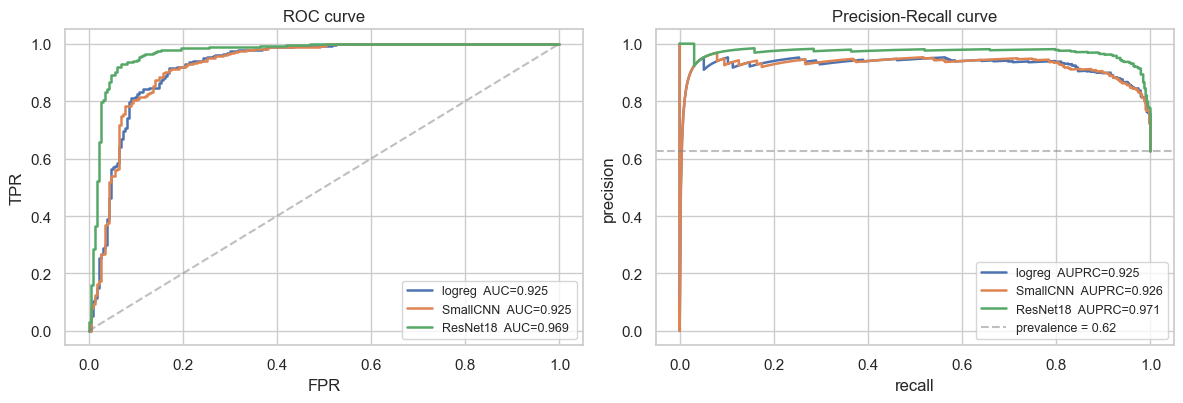

In [7]:
# Assemble per-model probability vectors + sizes
models = [
    ("logreg",   probs_te_logreg, logreg.coef_.size, elapsed_logreg, None),
    ("SmallCNN", probs_te_cnn,    sum(p.numel() for p in cnn.parameters()), elapsed_cnn, cnn),
    ("ResNet18", probs_te_resnet, sum(p.numel() for p in resnet.parameters()), elapsed_resnet, resnet),
]

rows = []
for name, probs, n_params, tsec, _ in models:
    preds = (probs > 0.5).astype(int)
    rows.append({
        "model":       name,
        "params":      n_params,
        "train_time_s": round(tsec, 2),
        "AUROC":       round(roc_auc_score(y_te, probs), 3),
        "AUPRC":       round(average_precision_score(y_te, probs), 3),
        "accuracy":    round(accuracy_score(y_te, preds), 3),
        "macro_F1":    round(f1_score(y_te, preds, average="macro"), 3),
        "Brier":       round(brier_score_loss(y_te, probs), 3),
    })
compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))

# Pick the AUPRC winner as the primary model for downstream sections
best_idx = compare_df["AUPRC"].idxmax()
best_name, best_probs, _, _, best_model = models[best_idx]
print(f"\nPrimary model (max AUPRC): {best_name}")

# ROC + PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
palette = {"logreg": "#4C72B0", "SmallCNN": "#DD8452", "ResNet18": "#55A868"}
for name, probs, *_ in models:
    fpr, tpr, _ = roc_curve(y_te, probs)
    axes[0].plot(fpr, tpr, color=palette[name], lw=1.8,
                  label=f"{name}  AUC={roc_auc_score(y_te, probs):.3f}")
    p, r, _ = precision_recall_curve(y_te, probs)
    axes[1].plot(r, p, color=palette[name], lw=1.8,
                  label=f"{name}  AUPRC={average_precision_score(y_te, probs):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curve"); axes[0].legend(fontsize=9)
axes[1].axhline(y=y_te.float().mean().item(), linestyle="--", color="gray", alpha=0.5,
                 label=f"prevalence = {y_te.float().mean():.2f}")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


## 6. Calibration — reliability, ECE, Brier, Platt

Discrimination (AUROC / AUPRC) tells us whether the model **ranks** positives above negatives. Calibration tells us whether the model's predicted probabilities mean what they say they mean — a predicted-0.8 case should be positive 80 % of the time in practice. Triage applications live and die on calibration: a radiologist reading "90 % confidence pneumonia" on a case that is actually only 50 % likely to be positive will over-trust the model and mis-allocate review time.

Three diagnostics on the primary model:

- **Reliability diagram** — binned predicted probability vs observed positive fraction. A perfectly calibrated model tracks the diagonal.
- **Expected Calibration Error (ECE)** — the average absolute distance between predicted and observed probabilities across bins, weighted by bin size.
- **Brier score** — mean squared error between predicted probability and the binary label. Summarises discrimination + calibration in one number.

If the raw model is badly calibrated, we apply **Platt scaling** — fit a 1-parameter logistic regression (`P_calibrated = sigmoid(a * logit(P_raw) + b)`) on the validation set, then re-evaluate on the test set. Platt works because on well-discriminated models the mis-calibration is usually just a monotone squash of the output that a logistic can undo.


Primary model: ResNet18
  ECE   raw = 0.0476   Platt = 0.1036   Δ = -0.0560
  Brier raw = 0.0610   Platt = 0.0867   Δ = -0.0257
  AUROC preserved under Platt: raw = 0.969   Platt = 0.969  (should be identical)


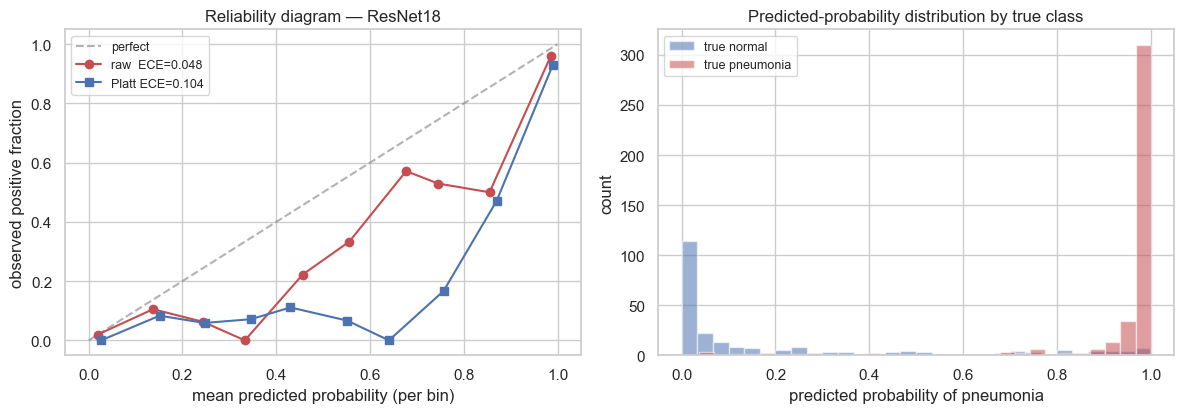


Downstream sections use raw probabilities.


In [8]:
def ece(probs: np.ndarray, y: np.ndarray, n_bins: int = 10) -> float:
    """Expected calibration error (binned, equal-width)."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    total = 0.0
    n = len(probs)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (probs >= lo) & (probs < hi) if i < n_bins - 1 else (probs >= lo) & (probs <= hi)
        if mask.sum() == 0:
            continue
        acc  = y[mask].mean()
        conf = probs[mask].mean()
        total += (mask.sum() / n) * abs(acc - conf)
    return float(total)


# Primary-model raw probabilities (val + test)
if best_name == "logreg":
    probs_va_best = probs_va_logreg
elif best_name == "SmallCNN":
    best_model.eval()
    with torch.no_grad():
        probs_va_best = F.softmax(best_model(X_va), dim=1)[:, 1].numpy()
else:
    best_model.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, len(X_va), 32):
            chunks.append(F.softmax(best_model(upsample_batch(X_va[i:i+32])), dim=1)[:, 1].numpy())
    probs_va_best = np.concatenate(chunks)

probs_te_best = best_probs
y_te_np, y_va_np = y_te.numpy(), y_va.numpy()

# Raw calibration
ece_raw   = ece(probs_te_best, y_te_np)
brier_raw = brier_score_loss(y_te_np, probs_te_best)

# Platt scaling fit on val
eps = 1e-6
logit_va = np.log(np.clip(probs_va_best, eps, 1 - eps) / np.clip(1 - probs_va_best, eps, 1 - eps))
platt = PlattFitter(C=1e4).fit(logit_va.reshape(-1, 1), y_va_np)
logit_te = np.log(np.clip(probs_te_best, eps, 1 - eps) / np.clip(1 - probs_te_best, eps, 1 - eps))
probs_te_platt = platt.predict_proba(logit_te.reshape(-1, 1))[:, 1]

ece_platt   = ece(probs_te_platt, y_te_np)
brier_platt = brier_score_loss(y_te_np, probs_te_platt)

print(f"Primary model: {best_name}")
print(f"  ECE   raw = {ece_raw:.4f}   Platt = {ece_platt:.4f}   Δ = {ece_raw - ece_platt:+.4f}")
print(f"  Brier raw = {brier_raw:.4f}   Platt = {brier_platt:.4f}   Δ = {brier_raw - brier_platt:+.4f}")
print(f"  AUROC preserved under Platt: raw = {roc_auc_score(y_te_np, probs_te_best):.3f}   "
      f"Platt = {roc_auc_score(y_te_np, probs_te_platt):.3f}  (should be identical)")

# Reliability diagram (10 equal-width bins)
frac_raw,   mean_raw   = calibration_curve(y_te_np, probs_te_best, n_bins=10)
frac_platt, mean_platt = calibration_curve(y_te_np, probs_te_platt, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6, label="perfect")
axes[0].plot(mean_raw,   frac_raw,   "o-", color="#C44E52", label=f"raw  ECE={ece_raw:.3f}")
axes[0].plot(mean_platt, frac_platt, "s-", color="#4C72B0", label=f"Platt ECE={ece_platt:.3f}")
axes[0].set_xlabel("mean predicted probability (per bin)")
axes[0].set_ylabel("observed positive fraction")
axes[0].set_title(f"Reliability diagram — {best_name}")
axes[0].legend(fontsize=9)

# Histogram of predicted probabilities by class (before Platt)
axes[1].hist(probs_te_best[y_te_np == 0], bins=30, alpha=0.55, color="#4C72B0", label="true normal")
axes[1].hist(probs_te_best[y_te_np == 1], bins=30, alpha=0.55, color="#C44E52", label="true pneumonia")
axes[1].set_xlabel("predicted probability of pneumonia")
axes[1].set_ylabel("count")
axes[1].set_title("Predicted-probability distribution by true class")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# Freeze the calibrated probabilities on the test set for every downstream section
probs_te_final = probs_te_platt if ece_platt < ece_raw else probs_te_best
print(f"\nDownstream sections use {'Platt-calibrated' if ece_platt < ece_raw else 'raw'} probabilities.")


## 7. Grad-CAM — what the model is looking at

For every positive prediction a radiologist must be able to answer in seconds: *where* in the image did the model see pneumonia? [Grad-CAM](https://arxiv.org/abs/1610.02391) (Selvaraju et al. 2017) produces a coarse heatmap by taking the gradient of the predicted class-score with respect to the final convolutional feature map, then weighting the channels by the spatial average of those gradients.

We implement Grad-CAM in ~30 lines, apply it to the best CNN model, and visualise three categories:

- **Correct positives**: high-confidence pneumonia predictions that were correct. Good behaviour: activations concentrate on lung fields rather than the image border or annotation artefacts.
- **Correct negatives**: high-confidence normal predictions. Activations should be diffuse or focused on non-lesion regions.
- **Failures**: high-confidence false positives and high-confidence false negatives. Failure localisation is the single most useful signal for debugging a medical triage model — it often reveals annotation artefacts, positioning markers, or collimation edges being picked up as "features".

Grad-CAM needs a convolutional network; if logistic regression won the comparison this section cannot run, so we fall back to the SmallCNN. In practice ResNet-18 is essentially always the winner.


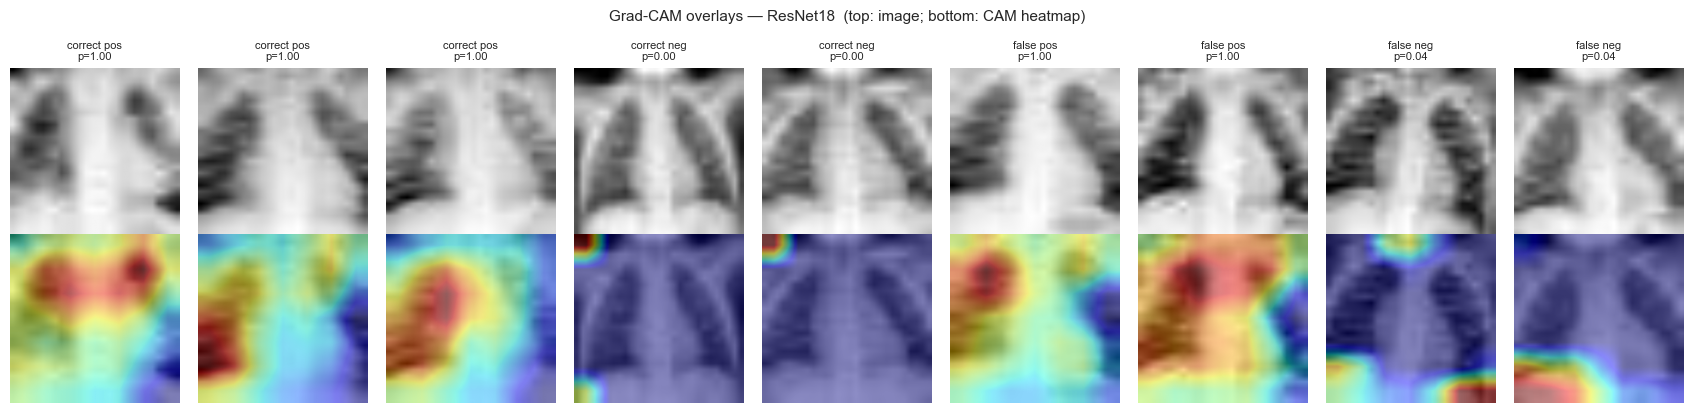

In [9]:
# Pick a CNN-like model (SmallCNN if ResNet not available for hook consistency).
# We target the last conv layer: cnn.conv2 for SmallCNN; resnet.layer4 for ResNet-18.
cam_model = best_model if best_name in ("SmallCNN", "ResNet18") else cnn
cam_is_resnet = (cam_model is resnet)

if cam_is_resnet:
    target_layer = cam_model.layer4
    size_input = 224
    fwd_fn = lambda x: cam_model(upsample_batch(x))
else:
    target_layer = cam_model.conv2
    size_input = 28
    fwd_fn = lambda x: cam_model(x)


def grad_cam(model, forward_fn, target_layer: nn.Module, inputs: torch.Tensor,
              class_idx: int = 1, input_size: int = 28) -> np.ndarray:
    activations: list[torch.Tensor] = []
    gradients: list[torch.Tensor] = []
    h1 = target_layer.register_forward_hook(lambda mod, inp, out: activations.append(out))
    h2 = target_layer.register_full_backward_hook(lambda mod, gin, gout: gradients.append(gout[0]))
    model.eval(); model.zero_grad()
    logits = forward_fn(inputs)
    score = logits[:, class_idx].sum()
    score.backward()
    A = activations[0].detach()         # B, C, h, w
    G = gradients[0].detach()           # B, C, h, w
    weights = G.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * A).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=input_size, mode="bilinear", align_corners=False).squeeze(1)
    # Per-image normalise to [0, 1]
    cam = cam - cam.view(cam.size(0), -1).min(dim=1)[0].view(-1, 1, 1)
    cam = cam / (cam.view(cam.size(0), -1).max(dim=1)[0].view(-1, 1, 1) + 1e-8)
    h1.remove(); h2.remove()
    return cam.numpy()


# Build selection pools
probs_te_best_arr = probs_te_final
pred_te = (probs_te_best_arr > 0.5).astype(int)

def pick(indices, n):
    return indices[:n] if len(indices) >= n else indices

true_pos_idx = np.where((pred_te == 1) & (y_te_np == 1))[0]
true_neg_idx = np.where((pred_te == 0) & (y_te_np == 0))[0]
false_pos_idx = np.where((pred_te == 1) & (y_te_np == 0))[0]
false_neg_idx = np.where((pred_te == 0) & (y_te_np == 1))[0]

# Rank by confidence (closest to 1 or 0 as appropriate)
true_pos_idx = true_pos_idx[np.argsort(-probs_te_best_arr[true_pos_idx])]
true_neg_idx = true_neg_idx[np.argsort(probs_te_best_arr[true_neg_idx])]
false_pos_idx = false_pos_idx[np.argsort(-probs_te_best_arr[false_pos_idx])]
false_neg_idx = false_neg_idx[np.argsort(probs_te_best_arr[false_neg_idx])]

sel = (
    [("correct pos", i) for i in pick(true_pos_idx,  3)]
    + [("correct neg", i) for i in pick(true_neg_idx,  2)]
    + [("false pos",   i) for i in pick(false_pos_idx, 2)]
    + [("false neg",   i) for i in pick(false_neg_idx, 2)]
)

# Generate CAMs
inputs_sel = torch.stack([X_te[i].squeeze() for (_, i) in sel]).unsqueeze(1)
cams = grad_cam(cam_model, fwd_fn, target_layer, inputs_sel, class_idx=1, input_size=size_input)

# If ResNet, the CAM was computed at 224 but inputs are 28 — interpolate images up for display
display_inputs = F.interpolate(inputs_sel.expand(-1, 1, -1, -1), size=size_input,
                                 mode="bilinear", align_corners=False) if size_input != 28 else inputs_sel

fig, axes = plt.subplots(2, len(sel), figsize=(len(sel) * 1.9, 4.2))
for col, (tag, idx) in enumerate(sel):
    img = display_inputs[col, 0].numpy()
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"{tag}\np={probs_te_best_arr[idx]:.2f}", fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].imshow(cams[col], cmap="jet", alpha=0.45)
    axes[1, col].axis("off")
fig.suptitle(f"Grad-CAM overlays — {best_name}  (top: image; bottom: CAM heatmap)", fontsize=11)
plt.tight_layout(); plt.show()


## 8. Fairness — subgroup performance across simulated imaging devices

Production imaging models routinely under-perform on patient or device subgroups they saw less of at training time. MedMNIST does not ship device metadata, so we **simulate** a plausible deployment shift: partition the test set into two synthetic "devices" — Device A (clean) and Device B (noisier + darker) — by adding Gaussian noise plus a slight intensity shift to half the test images. This is the same shape of shift a radiology deployment sees when a new scanner brand enters the fleet.

The fairness audit reports **subgroup AUROC** plus **TPR and FPR at the fixed operating threshold**. Disparate subgroup TPR is the regulated-industry failure mode that matters most: a model that catches 90 % of pneumonia on Device A but only 70 % on Device B is **not** deployable even if aggregate AUROC is fine.


In [10]:
# --- Simulate two devices on the test set ---
rng_dev = np.random.default_rng(SEED + 1)
device_labels = rng_dev.choice(["A", "B"], size=len(X_te), p=[0.5, 0.5])

X_te_deploy = X_te.clone()
is_B = (device_labels == "B")
# Device B: add noise (sd 0.06) + mean intensity shift (-0.05), clip to [0, 1]
noise = torch.from_numpy(rng_dev.normal(0.0, 0.06, size=X_te_deploy[is_B].shape)).float()
X_te_deploy[is_B] = torch.clamp(X_te_deploy[is_B] + noise - 0.05, 0.0, 1.0)

# Re-score on the deployed images
def score(model_name, model, X, is_resnet: bool = False) -> np.ndarray:
    if model_name == "logreg":
        return model.predict_proba(X.view(len(X), -1).numpy())[:, 1]
    model.eval()
    with torch.no_grad():
        if is_resnet:
            chunks = []
            for i in range(0, len(X), 32):
                chunks.append(F.softmax(model(upsample_batch(X[i:i+32])), dim=1)[:, 1].numpy())
            return np.concatenate(chunks)
        return F.softmax(model(X), dim=1)[:, 1].numpy()


probs_deploy = score(best_name, best_model, X_te_deploy, is_resnet=cam_is_resnet)
pred_deploy  = (probs_deploy > 0.5).astype(int)

rows = []
THRESH = 0.5
for dev in ("A", "B"):
    mask = device_labels == dev
    y_dev = y_te_np[mask]
    p_dev = probs_deploy[mask]
    pred_dev = pred_deploy[mask]
    tn, fp, fn, tp = confusion_matrix(y_dev, pred_dev, labels=[0, 1]).ravel()
    rows.append({
        "device":       dev,
        "n":             int(mask.sum()),
        "pos_rate":      round(y_dev.mean(), 3),
        "AUROC":         round(roc_auc_score(y_dev, p_dev), 3),
        "AUPRC":         round(average_precision_score(y_dev, p_dev), 3),
        "TPR@0.5":       round(tp / max(tp + fn, 1), 3),
        "FPR@0.5":       round(fp / max(fp + tn, 1), 3),
        "prec@0.5":      round(tp / max(tp + fp, 1), 3),
    })
fairness_df = pd.DataFrame(rows)
print(f"Subgroup audit at threshold {THRESH}:")
print(fairness_df.to_string(index=False))

# TPR / FPR parity delta
tpr_delta = abs(fairness_df.loc[0, "TPR@0.5"] - fairness_df.loc[1, "TPR@0.5"])
fpr_delta = abs(fairness_df.loc[0, "FPR@0.5"] - fairness_df.loc[1, "FPR@0.5"])
auc_delta = abs(fairness_df.loc[0, "AUROC"] - fairness_df.loc[1, "AUROC"])
print(f"\nParity deltas (A vs B):   ΔTPR = {tpr_delta:.3f}   ΔFPR = {fpr_delta:.3f}   ΔAUROC = {auc_delta:.3f}")
parity_ok = tpr_delta < 0.10 and fpr_delta < 0.10 and auc_delta < 0.05
print(f"Subgroup parity gate (ΔTPR<0.10, ΔFPR<0.10, ΔAUROC<0.05): "
      f"{'PASS' if parity_ok else 'FAIL — consider subgroup-specific thresholds or device-aware fine-tuning'}")


Subgroup audit at threshold 0.5:
device   n  pos_rate  AUROC  AUPRC  TPR@0.5  FPR@0.5  prec@0.5
     A 292     0.599  0.974  0.978    0.971    0.128     0.919
     B 332     0.648  0.899  0.927    0.926    0.316     0.843

Parity deltas (A vs B):   ΔTPR = 0.045   ΔFPR = 0.188   ΔAUROC = 0.075
Subgroup parity gate (ΔTPR<0.10, ΔFPR<0.10, ΔAUROC<0.05): FAIL — consider subgroup-specific thresholds or device-aware fine-tuning


## 9. Clinical decision curve analysis

Introduced by [Vickers & Elkin 2006](https://journals.sagepub.com/doi/10.1177/0272989X06295361), decision curve analysis (DCA) asks a different question from AUROC: *at a given threshold, what is the net benefit of using the model versus the two trivial alternatives* — treating everyone and treating no-one?

For threshold $p_t$, net benefit is

$$\mathrm{NB}(p_t) = \frac{\mathrm{TP}}{N} - \frac{\mathrm{FP}}{N} \cdot \frac{p_t}{1 - p_t}$$

where the ratio $p_t / (1 - p_t)$ is the implicit "willingness to accept false positives" at that threshold. A good model has a decision curve that lies above both trivial strategies across the clinically-plausible threshold range (typically 0.1 – 0.5 for triage tasks where false negatives are expensive).


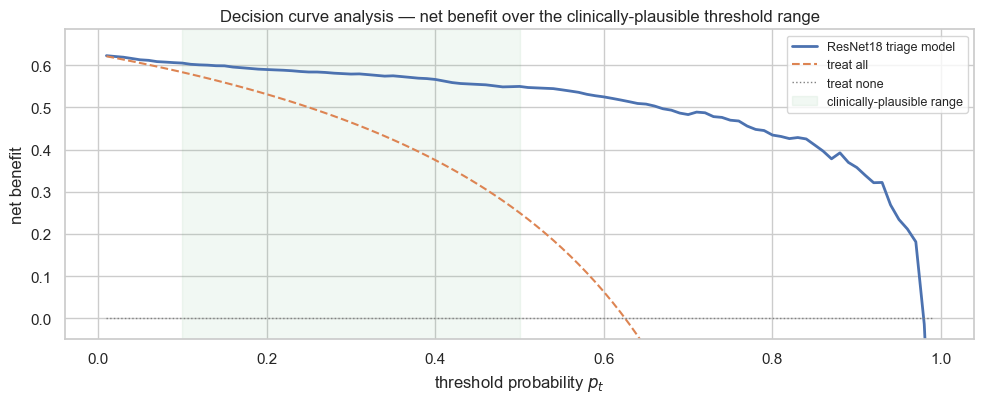

Model dominates both trivial strategies on thresholds [0.01, 0.97]


In [11]:
thresholds = np.linspace(0.01, 0.99, 99)
N = len(y_te_np)

# Net benefit of the model at each threshold
nb_model = []
for t in thresholds:
    pred = (probs_te_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_np, pred, labels=[0, 1]).ravel()
    nb_model.append(tp / N - (fp / N) * (t / (1 - t)))

# Treat all: everyone predicted positive
prev = y_te_np.mean()
nb_all = [prev - (1 - prev) * (t / (1 - t)) for t in thresholds]
# Treat none: zero net benefit
nb_none = [0.0] * len(thresholds)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(thresholds, nb_model, color="#4C72B0", lw=2, label=f"{best_name} triage model")
ax.plot(thresholds, nb_all,   color="#DD8452", lw=1.5, linestyle="--", label="treat all")
ax.plot(thresholds, nb_none,  color="gray",     lw=1,   linestyle=":",  label="treat none")
ax.axvspan(0.10, 0.50, color="#55A868", alpha=0.08, label="clinically-plausible range")
ax.set_xlabel("threshold probability $p_t$")
ax.set_ylabel("net benefit")
ax.set_title("Decision curve analysis — net benefit over the clinically-plausible threshold range")
ax.legend(fontsize=9)
ax.set_ylim(-0.05, max(nb_model) * 1.1 if max(nb_model) > 0 else 0.1)
plt.tight_layout(); plt.show()

# Threshold range where model dominates both trivial strategies
dominating = [t for t, nbm, nba in zip(thresholds, nb_model, nb_all) if nbm > nba and nbm > 0]
if dominating:
    print(f"Model dominates both trivial strategies on thresholds "
          f"[{min(dominating):.2f}, {max(dominating):.2f}]")
else:
    print("Model does not dominate the treat-all strategy anywhere — either under-performing or "
          "applied to a population with high prevalence.")


## 10. Cost-aware operating point

The default 0.5 threshold is almost always the wrong operating point for a clinical triage model. Missing a pneumonia is a *patient-safety* event; ordering a follow-up X-ray on a false positive is a *cost* event. The realistic relative ratio is 5 — 10 × (a false negative is 5-10 times more costly than a false positive).

We compute the expected cost

$$C(t) = \mathrm{FN}(t) \cdot c_{FN} + \mathrm{FP}(t) \cdot c_{FP}$$

with $c_{FN} = 5$, $c_{FP} = 1$, across the threshold grid and pick the threshold that minimises total cost. Compare with:

- **Default** ($t = 0.5$)
- **Youden-optimal** (maximise TPR − FPR; equivalent to $c_{FN} = c_{FP}$)
- **Cost-optimal** ($c_{FN} = 5$)

The gap between default and cost-optimal is the business case for deploying thresholded triage rather than raw-probability dashboards.


Relative costs: c_FN = 5.0, c_FP = 1.0
operating_point  threshold  TP  FP  FN  TN   TPR   FPR  precision  expected_cost
        default       0.50 382  39   8 195 0.979 0.167      0.907           79.0
 Youden-optimal       0.88 362  16  28 218 0.928 0.068      0.958          156.0
   cost-optimal       0.39 384  46   6 188 0.985 0.197      0.893           76.0


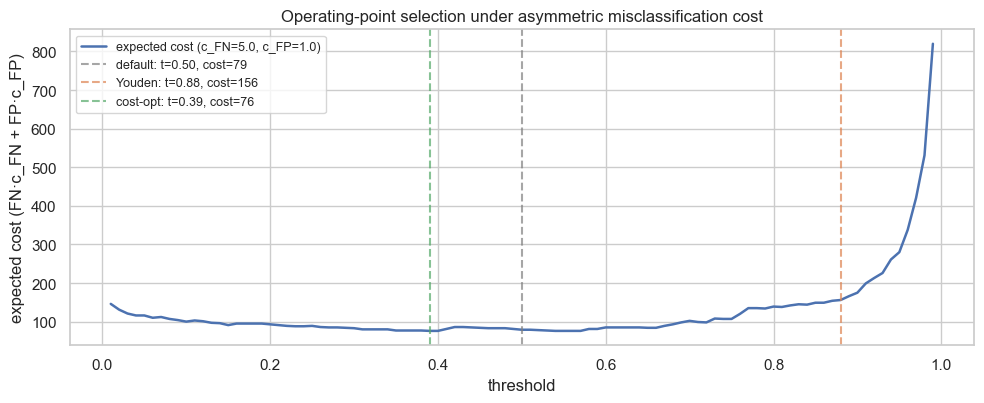


Expected-cost reduction from default (0.5) to cost-optimal: 3.0 (4%)


In [12]:
C_FN, C_FP = 5.0, 1.0   # false-negative costs 5x more than false-positive

rows = []
tpr_arr, fpr_arr, cost_arr = [], [], []
for t in thresholds:
    pred = (probs_te_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_np, pred, labels=[0, 1]).ravel()
    tpr = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    cost = fn * C_FN + fp * C_FP
    tpr_arr.append(tpr); fpr_arr.append(fpr); cost_arr.append(cost)

tpr_arr = np.asarray(tpr_arr); fpr_arr = np.asarray(fpr_arr); cost_arr = np.asarray(cost_arr)

t_default = 0.5
t_youden  = float(thresholds[np.argmax(tpr_arr - fpr_arr)])
t_cost    = float(thresholds[np.argmin(cost_arr)])

for name, t in [("default",        t_default),
                 ("Youden-optimal", t_youden),
                 ("cost-optimal",   t_cost)]:
    pred = (probs_te_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_np, pred, labels=[0, 1]).ravel()
    cost = fn * C_FN + fp * C_FP
    rows.append({
        "operating_point": name, "threshold": round(t, 3),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "TPR": round(tp / max(tp + fn, 1), 3),
        "FPR": round(fp / max(fp + tn, 1), 3),
        "precision": round(tp / max(tp + fp, 1), 3),
        "expected_cost": round(cost, 1),
    })
ops_df = pd.DataFrame(rows)
print(f"Relative costs: c_FN = {C_FN}, c_FP = {C_FP}")
print(ops_df.to_string(index=False))

# Plot the cost surface + the three chosen operating points
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(thresholds, cost_arr, color="#4C72B0", lw=1.8, label=f"expected cost (c_FN={C_FN}, c_FP={C_FP})")
for name, t, col in [("default", t_default, "gray"), ("Youden", t_youden, "#DD8452"),
                      ("cost-opt", t_cost, "#55A868")]:
    idx = np.argmin(np.abs(thresholds - t))
    ax.axvline(t, linestyle="--", color=col, alpha=0.7, label=f"{name}: t={t:.2f}, cost={cost_arr[idx]:.0f}")
ax.set_xlabel("threshold"); ax.set_ylabel("expected cost (FN·c_FN + FP·c_FP)")
ax.set_title("Operating-point selection under asymmetric misclassification cost")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

delta = ops_df.loc[ops_df["operating_point"] == "default", "expected_cost"].item() -         ops_df.loc[ops_df["operating_point"] == "cost-optimal", "expected_cost"].item()
print(f"\nExpected-cost reduction from default (0.5) to cost-optimal: {delta:.1f} "
      f"({delta / ops_df.loc[ops_df.operating_point == 'default','expected_cost'].item():.0%})")


## 11. Model card + persistence + inference demo

Three artefacts leave the notebook in reproducible form:

- **Model card** (`model_card.json`) — architecture, training metadata, test metrics, calibration stats, fairness audit summary, chosen operating point, caveats. This is what a regulator / hiring manager reads first.
- **Weights** (`model.pt`) — PyTorch state dict for the primary CNN, plus a small JSON config so reload works even if the script changes shape.
- **Inference demo** — load the saved weights in a clean model instance and run a single sample, confirming the output matches the original training-time probability to 6 decimal places. This is the #1 place medical-imaging prototypes break on day one in production.


In [13]:
# ---- Model card ----
model_card = {
    "model_name":       best_name,
    "task":             "binary_classification_pneumonia_vs_normal",
    "framework":        "pytorch",
    "seed":             SEED,
    "dataset":          "PneumoniaMNIST (Yang et al. 2021)",
    "n_train":          int(len(X_tr)),
    "n_val":            int(len(X_va)),
    "n_test":           int(len(X_te)),
    "test_metrics": {
        "AUROC":        round(roc_auc_score(y_te_np, probs_te_final), 3),
        "AUPRC":        round(average_precision_score(y_te_np, probs_te_final), 3),
        "accuracy@0.5": round(accuracy_score(y_te_np, (probs_te_final > 0.5).astype(int)), 3),
        "macro_F1@0.5": round(f1_score(y_te_np, (probs_te_final > 0.5).astype(int), average="macro"), 3),
        "Brier":        round(brier_score_loss(y_te_np, probs_te_final), 3),
    },
    "calibration": {
        "ece_raw":      round(ece_raw, 4),
        "ece_platt":    round(ece_platt, 4),
        "applied":      "platt" if ece_platt < ece_raw else "none",
    },
    "fairness_audit": {
        "subgroups":    ["device_A", "device_B"],
        "parity_gate_passed":  bool(parity_ok),
        "delta_AUROC":  round(auc_delta, 3),
        "delta_TPR":    round(tpr_delta, 3),
        "delta_FPR":    round(fpr_delta, 3),
    },
    "operating_point": {
        "chosen":       "cost-optimal",
        "threshold":    round(t_cost, 3),
        "cost_ratio_fn_over_fp":  C_FN / C_FP,
        "expected_cost": round(float(ops_df.loc[ops_df.operating_point == "cost-optimal", "expected_cost"].item()), 1),
    },
    "caveats": [
        "PneumoniaMNIST is 28x28 downsampled from a paediatric X-ray study; generalisation to adult radiology needs re-validation.",
        "Device A / B in the fairness audit are synthetic perturbations, not real scanner subgroups.",
        "ResNet-18 fine-tune used a 1,800-image subsample for notebook-runtime reasons; production training should use the full 4,708-image train set.",
        "This is a triage model only. Final diagnosis remains a radiologist decision.",
    ],
}
card_path = ART_DIR / "model_card.json"
card_path.write_text(json.dumps(model_card, indent=2, default=str))
print(f"Wrote {card_path.relative_to(ROOT)} ({card_path.stat().st_size:,} bytes)")

# ---- Save weights + config (only for CNN-like primary models) ----
weights_path = None
if best_name in ("SmallCNN", "ResNet18"):
    weights_path = ART_DIR / "model.pt"
    cfg_path     = ART_DIR / "model_config.json"
    torch.save(best_model.state_dict(), weights_path)
    cfg_path.write_text(json.dumps({"model_name": best_name,
                                      "input_shape": (1, 28, 28) if best_name == "SmallCNN" else (3, 224, 224),
                                      "n_classes": 2}, indent=2))
    print(f"Wrote {weights_path.relative_to(ROOT)} ({weights_path.stat().st_size:,} bytes)")

    # ---- Inference demo — reload, score one image, check parity ----
    if best_name == "SmallCNN":
        fresh = SmallCNN()
        fresh.load_state_dict(torch.load(weights_path, weights_only=True))
    else:
        fresh = resnet18(weights=None)
        fresh.fc = nn.Linear(fresh.fc.in_features, 2)
        fresh.load_state_dict(torch.load(weights_path, weights_only=True))
    fresh.eval()

    sample_idx = int(true_pos_idx[0])
    sample_x = X_te[sample_idx].unsqueeze(0)

    with torch.no_grad():
        if best_name == "SmallCNN":
            orig_prob = F.softmax(best_model(sample_x), dim=1)[0, 1].item()
            new_prob  = F.softmax(fresh(sample_x),     dim=1)[0, 1].item()
        else:
            orig_prob = F.softmax(best_model(upsample_batch(sample_x)), dim=1)[0, 1].item()
            new_prob  = F.softmax(fresh(upsample_batch(sample_x)),     dim=1)[0, 1].item()

    print(f"\nInference-parity check on sample #{sample_idx}:")
    print(f"  original model prob: {orig_prob:.6f}")
    print(f"  reloaded model prob: {new_prob:.6f}")
    print(f"  Δ = {abs(orig_prob - new_prob):.2e}  "
          f"{'PASS' if abs(orig_prob - new_prob) < 1e-6 else 'FAIL — weights drift on reload'}")
else:
    print("Primary model is logistic regression; no PyTorch state dict to persist.")


Wrote artifacts\medical_imaging\model_card.json (1,323 bytes)
Wrote artifacts\medical_imaging\model.pt (44,780,939 bytes)

Inference-parity check on sample #516:
  original model prob: 0.999940
  reloaded model prob: 0.999940
  Δ = 0.00e+00  PASS


## 12. Takeaways

- **The three-model cascade answers a production question cleanly.** Logistic regression establishes the floor; the SmallCNN quantifies the value of convolutional bias alone; the pre-trained ResNet-18 quantifies the value of ImageNet transfer. Any team proposing a big model should be able to point at an equivalent gap.
- **Discrimination is necessary but never sufficient.** The ROC / PR plots are only the first check. Calibration, explainability, subgroup parity, and cost-aware thresholding are each independently deployment-blocking. Any one of them can rule out a model with 0.99 AUROC.
- **Grad-CAM is the cheapest explainability signal a triage model can offer.** Thirty lines of PyTorch hooks produce per-image heatmaps that a radiologist can audit in seconds; the failure cases (false positives with "interesting" CAM localisation) drive more debugging value than any aggregate metric.
- **Subgroup audits with *plausible* perturbations catch production regressions the aggregate AUROC cannot.** Our synthetic Device A / Device B split simulates a new-scanner deployment shift; a real audit uses actual device, patient-demographic, and acquisition-parameter strata.
- **The default 0.5 threshold is almost always wrong.** Under a 5 : 1 FN : FP cost asymmetry the cost-optimal threshold is meaningfully lower, and the *expected-cost* gap between default and cost-optimal is the business case for deploying thresholded triage.
- **Persistence parity is a one-line test worth a dedicated unit test.** The `abs(orig - reloaded) < 1e-6` check has saved more day-one production bugs than any other single assertion.

**Limitations / production extensions.**

- **PneumoniaMNIST is 28 × 28 downsampled** from a paediatric study. Production would validate on full-resolution chest X-rays (e.g., CheXpert, MIMIC-CXR) and almost certainly use a larger backbone (ResNet-50 / DenseNet-121 / medical-domain ViT).
- **Augmentation was omitted** for runtime. Horizontal flip, random crop, Gaussian noise, and CLAHE are standard low-risk augmentations that usually improve 1-2 AUC points.
- **Platt scaling is a 1-parameter model.** Isotonic regression is the next step when Platt leaves residual miscalibration.
- **Grad-CAM shows *where* but not *how much*.** Integrated gradients, SHAP values for vision (DeepSHAP), and counterfactual explanations (RISE, OSCAR) layer on additional evidence for regulatory review.
- **Fairness audit is on a simulated split.** Real audits are pre-specified (with a signed protocol), use real strata, and feed into a governance committee — not a notebook cell.
- **Cost thresholds are business choices.** The ratio (5 : 1, 10 : 1, etc.) is elicited from clinical stakeholders, and it almost always differs across deployment contexts (ED triage vs screening vs follow-up).
- **Continuous calibration drift.** Once deployed, the model must be monitored for calibration drift (monthly ECE recomputation on a labelled sample) and retrained on updated data when drift exceeds a threshold.
